In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
import os
os.listdir("/content/drive/MyDrive/Data Science/")

['covid_19.csv']

In [5]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Data Science/covid_19.csv")
df.head()

,country,date,new_cases,total_cases,new_deaths,total_deaths,weekly_cases,weekly_deaths,weekly_pct_growth_cases,weekly_pct_growth_deaths,...,cfr_100_cases,cfr_short_term,days_since_100_total_cases,days_since_5_total_deaths,days_since_1_total_cases_per_million,days_since_0_1_total_deaths_per_million,days_since_100_total_cases_and_5m_pop,total_deaths_last12m,total_deaths_per_100k_last12m,total_deaths_per_million_last12m
0,Afghanistan,2020-01-04,0.0,0,0.0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,-86.0,-91.0,-81.0,-91.0,-86.0,NaN,NaN,NaN
1,Afghanistan,2020-01-05,0.0,0,0.0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,-85.0,-90.0,-80.0,-90.0,-85.0,NaN,NaN,NaN
2,Afghanistan,2020-01-06,0.0,0,0.0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,-84.0,-89.0,-79.0,-89.0,-84.0,NaN,NaN,NaN
3,Afghanistan,2020-01-07,0.0,0,0.0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,-83.0,-88.0,-78.0,-88.0,-83.0,NaN,NaN,NaN
4,Afghanistan,2020-01-08,0.0,0,0.0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,-82.0,-87.0,-77.0,-87.0,-82.0,NaN,NaN,NaN


In [6]:
df.columns

Index(['country', 'date', 'new_cases', 'total_cases', 'new_deaths',
       'total_deaths', 'weekly_cases', 'weekly_deaths',
       'weekly_pct_growth_cases', 'weekly_pct_growth_deaths', 'biweekly_cases',
       'biweekly_deaths', 'biweekly_pct_growth_cases',
       'biweekly_pct_growth_deaths', 'new_cases_per_million',
       'new_deaths_per_million', 'total_cases_per_million',
       'total_deaths_per_million', 'weekly_cases_per_million',
       'weekly_deaths_per_million', 'biweekly_cases_per_million',
       'biweekly_deaths_per_million', 'total_deaths_per_100k',
       'new_deaths_per_100k', 'new_cases_7_day_avg_right',
       'new_deaths_7_day_avg_right', 'new_cases_per_million_7_day_avg_right',
       'new_deaths_per_million_7_day_avg_right',
       'new_deaths_per_100k_7_day_avg_right', 'cfr', 'cfr_100_cases',
       'cfr_short_term', 'days_since_100_total_cases',
       'days_since_5_total_deaths', 'days_since_1_total_cases_per_million',
       'days_since_0_1_total_deaths_per_

In [ ]:
df.shape

(579174, 40)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 579174 entries, 0 to 579173
Data columns (total 40 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   country                                  579174 non-null  object 
 1   date                                     579174 non-null  object 
 2   new_cases                                574898 non-null  float64
 3   total_cases                              579174 non-null  int64  
 4   new_deaths                               576007 non-null  float64
 5   total_deaths                             579174 non-null  int64  
 6   weekly_cases                             573643 non-null  float64
 7   weekly_deaths                            574762 non-null  float64
 8   weekly_pct_growth_cases                  347939 non-null  float64
 9   weekly_pct_growth_deaths                 219078 non-null  float64
 10  biweekly_cases                  

In [7]:
df.isnull().sum()

,0
country,0
date,0
new_cases,4276
total_cases,0
new_deaths,3167
total_deaths,0
weekly_cases,5531
weekly_deaths,4412
weekly_pct_growth_cases,231235
weekly_pct_growth_deaths,360096


In [8]:
df = df.fillna(0)

In [9]:
df['date'] = pd.to_datetime(df['date'])

In [12]:
# filter italy
df = df[df['country'] == 'Italy']
print(df)

       country       date  new_cases  total_cases  new_deaths  total_deaths  \
248882   Italy 2020-01-04        0.0            0         0.0             0   
248883   Italy 2020-01-05        0.0            0         0.0             0   
248884   Italy 2020-01-06        0.0            0         0.0             0   
248885   Italy 2020-01-07        0.0            0         0.0             0   
248886   Italy 2020-01-08        0.0            0         0.0             0   
...        ...        ...        ...          ...         ...           ...   
251203   Italy 2026-05-13        0.0     26969913         0.0        198523   
251204   Italy 2026-05-14        0.0     26969913         0.0        198523   
251205   Italy 2026-05-15        0.0     26969913         0.0        198523   
251206   Italy 2026-05-16        0.0     26969913         0.0        198523   
251207   Italy 2026-05-17        0.0     26969913         0.0        198523   

        weekly_cases  weekly_deaths  weekly_pct_gro

In [13]:
# sort by date
df = df.sort_values('date')

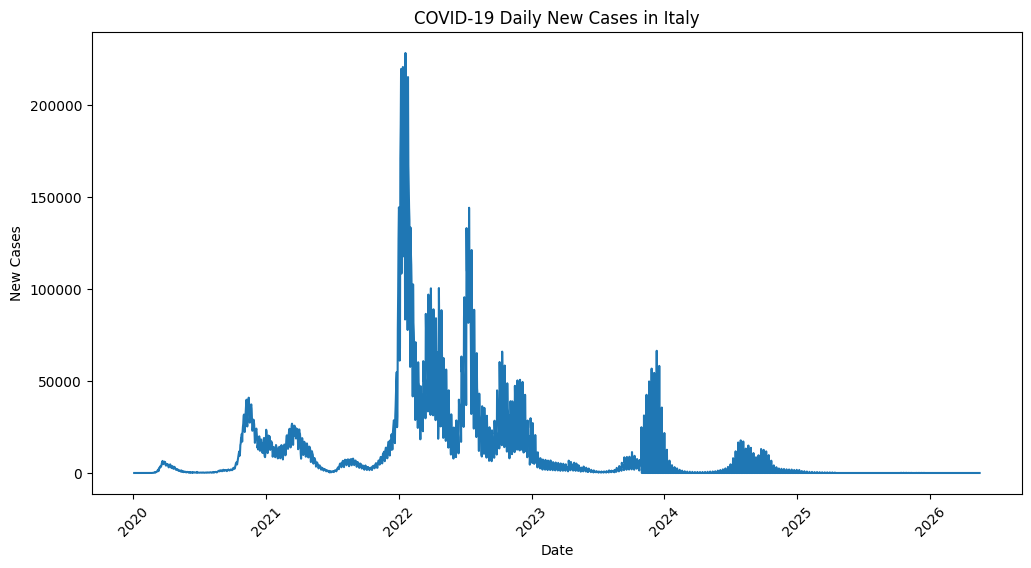

In [14]:
# Daily Cases in Italy
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['new_cases'])
plt.title("COVID-19 Daily New Cases in Italy")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.xticks(rotation=45)
plt.show()

In [15]:
# Basic statistics
df.describe()

,date,new_cases,total_cases,new_deaths,total_deaths,weekly_cases,weekly_deaths,weekly_pct_growth_cases,weekly_pct_growth_deaths,biweekly_cases,...,cfr_100_cases,cfr_short_term,days_since_100_total_cases,days_since_5_total_deaths,days_since_1_total_cases_per_million,days_since_0_1_total_deaths_per_million,days_since_100_total_cases_and_5m_pop,total_deaths_last12m,total_deaths_per_100k_last12m,total_deaths_per_million_last12m
count,2326,2326.000000,2.326000e+03,2326.000000,2326.000000,2.326000e+03,2326.000000,2326.000000,2326.000000,2.326000e+03,...,2326.000000,2326.000000,2326.000000,2326.000000,2326.000000,2326.000000,2326.000000,2326.0,2326.0,2326.0
mean,2023-03-11 12:00:00,11594.975494,1.768722e+07,85.349527,153171.809114,8.116483e+04,597.446690,6.236715,7.327644,1.623297e+05,...,2.410153,0.837097,1111.500000,1110.500000,1112.500000,1110.500000,1111.500000,0.0,0.0,0.0
min,2020-01-04 00:00:00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,-100.000000,-100.000000,0.000000e+00,...,0.000000,0.000000,-51.000000,-52.000000,-50.000000,-52.000000,-51.000000,0.0,0.0,0.0
25%,2021-08-07 06:00:00,0.000000,4.385511e+06,0.000000,128192.500000,7.640000e+02,15.000000,-16.675000,-14.400000,1.442000e+03,...,0.735441,0.000000,530.250000,529.250000,531.250000,529.250000,530.250000,0.0,0.0,0.0
50%,2023-03-11 12:00:00,1250.000000,2.563276e+07,16.000000,188582.000000,1.321250e+04,141.000000,-1.200000,0.000000,2.756400e+04,...,0.736126,0.595123,1111.500000,1110.500000,1112.500000,1110.500000,1111.500000,0.0,0.0,0.0
75%,2024-10-12 18:00:00,11350.500000,2.691998e+07,87.000000,197555.000000,8.533600e+04,584.750000,11.775000,12.300000,1.707985e+05,...,2.799393,1.289279,1692.750000,1691.750000,1693.750000,1691.750000,1692.750000,0.0,0.0,0.0
max,2026-05-17 00:00:00,228123.000000,2.696991e+07,993.000000,198523.000000,1.272752e+06,5750.000000,6121.400000,1250.000000,2.520094e+06,...,14.500951,4.945055,2274.000000,2273.000000,2275.000000,2273.000000,2274.000000,0.0,0.0,0.0
std,NaN,25890.004522,1.105108e+07,154.856799,60882.866479,1.718543e+05,1048.151117,138.108153,70.080206,3.399096e+05,...,3.622520,0.896569,671.602685,671.602685,671.602685,671.602685,671.602685,0.0,0.0,0.0


#Key Insights from Your Summary

##From the statistics:

###Dataset contains 2,326 records.
###Covers approximately January 2020 to May 2026.
###Maximum daily cases reached 228,123.
###Maximum daily deaths reached 993.
###Average daily cases were around 11,595.
###Average daily deaths were around 85.
###Total confirmed cases reached nearly 27 million.

In [16]:
total_cases = df['total_cases'].max()
total_deaths = df['total_deaths'].max()

peak_cases = df['new_cases'].max()
peak_deaths = df['new_deaths'].max()

print(f"Total Cases: {total_cases:,.0f}")
print(f"Total Deaths: {total_deaths:,.0f}")
print(f"Peak Daily Cases: {peak_cases:,.0f}")
print(f"Peak Daily Deaths: {peak_deaths:,.0f}")

Total Cases: 26,969,913
Total Deaths: 198,523
Peak Daily Cases: 228,123
Peak Daily Deaths: 993


## Monthly Trend Analysis

In [17]:
monthly = df.resample('M', on='date').agg({
    'new_cases':'sum',
    'new_deaths':'sum'
})

monthly.head()

/tmp/ipykernel_1141/2137195378.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample('M', on='date').agg({


,new_cases,new_deaths
date,,
2020-01-31,3.0,0.0
2020-02-29,885.0,21.0
2020-03-31,100851.0,11570.0
2020-04-30,101852.0,16091.0
2020-05-31,29073.0,5658.0


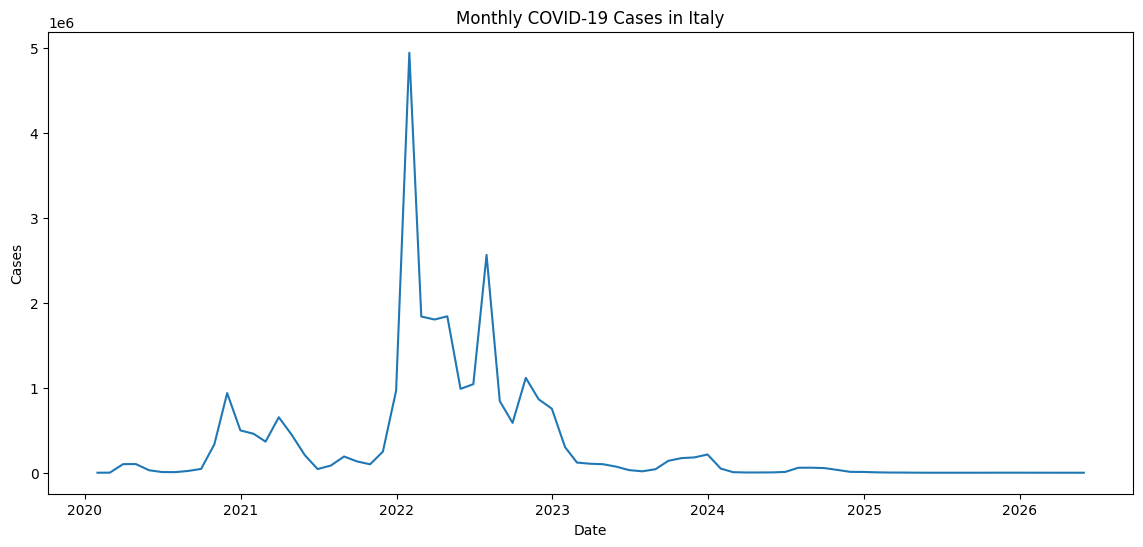

In [18]:
plt.figure(figsize=(14,6))
plt.plot(monthly.index, monthly['new_cases'])

plt.title('Monthly COVID-19 Cases in Italy')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.show()

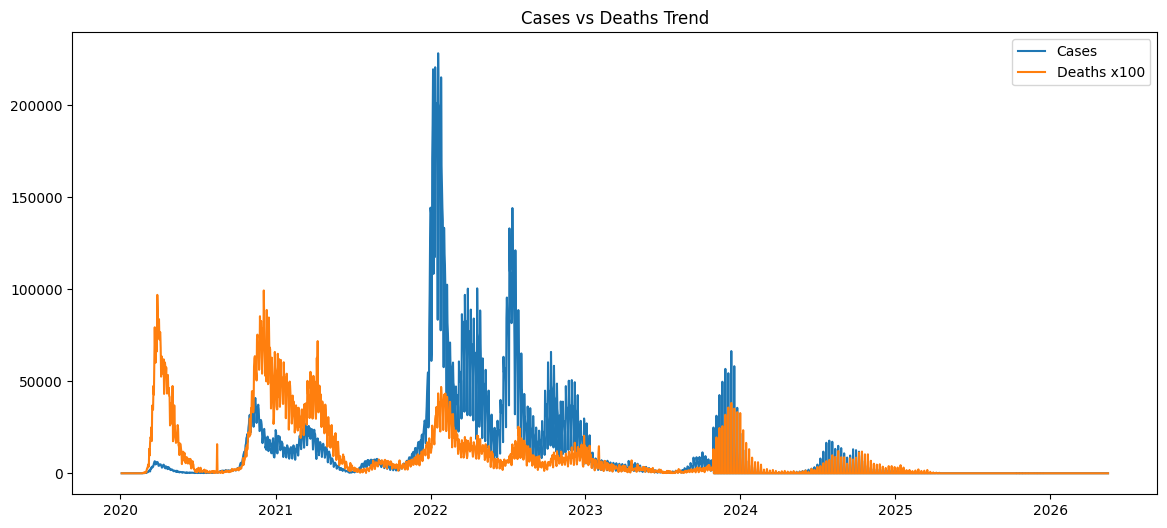

In [19]:
plt.figure(figsize=(14,6))

plt.plot(df['date'], df['new_cases'], label='Cases')
plt.plot(df['date'], df['new_deaths']*100, label='Deaths x100')

plt.legend()
plt.title('Cases vs Deaths Trend')
plt.show()

## Distribution Analysis

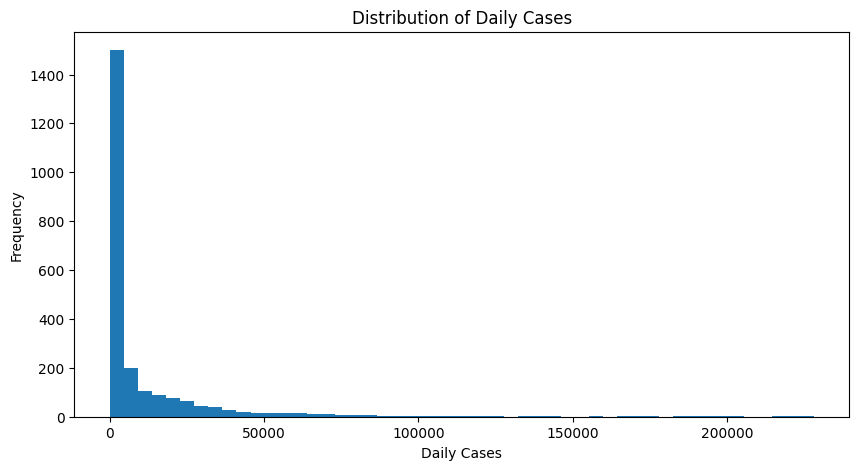

In [20]:
plt.figure(figsize=(10,5))

plt.hist(df['new_cases'], bins=50)

plt.title('Distribution of Daily Cases')
plt.xlabel('Daily Cases')
plt.ylabel('Frequency')
plt.show()

## Correlation Heatmap

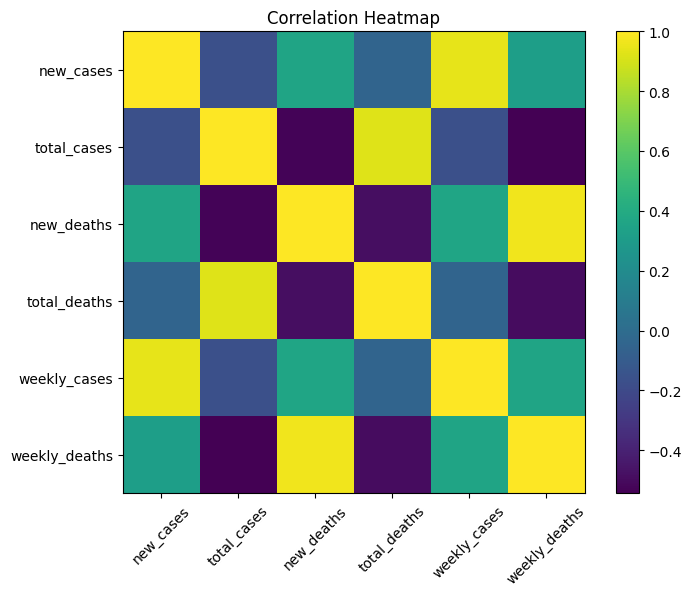

In [21]:
import matplotlib.pyplot as plt

cols = [
    'new_cases',
    'total_cases',
    'new_deaths',
    'total_deaths',
    'weekly_cases',
    'weekly_deaths'
]

corr = df[cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)

plt.title("Correlation Heatmap")
plt.show()

## Advanced Analysis: Mortality Rate Trend

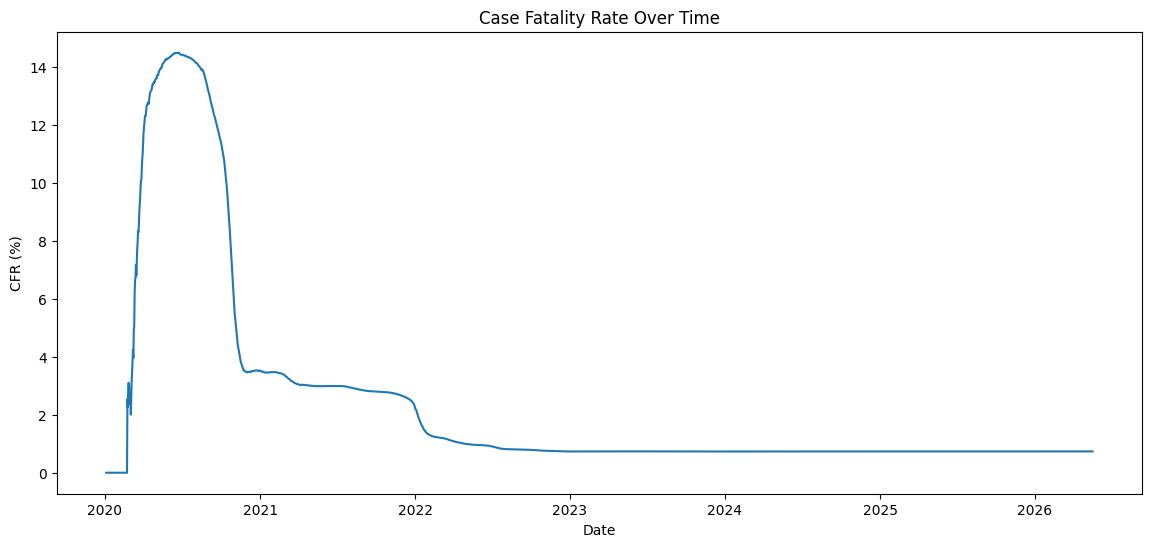

In [22]:
plt.figure(figsize=(14,6))

plt.plot(df['date'], df['cfr'])

plt.title('Case Fatality Rate Over Time')
plt.xlabel('Date')
plt.ylabel('CFR (%)')

plt.show()

In [23]:
#Top Findings table
summary = pd.DataFrame({
    'Metric': [
        'Total Cases',
        'Total Deaths',
        'Peak Daily Cases',
        'Peak Daily Deaths'
    ],
    'Value': [
        df['total_cases'].max(),
        df['total_deaths'].max(),
        df['new_cases'].max(),
        df['new_deaths'].max()
    ]
})

summary

,Metric,Value
0,Total Cases,26969913.0
1,Total Deaths,198523.0
2,Peak Daily Cases,228123.0
3,Peak Daily Deaths,993.0


# Highest Cases Day

In [24]:
peak_cases_row = df.loc[df['new_cases'].idxmax()]
peak_cases_row[['date', 'new_cases']]

,249628
date,2022-01-19 00:00:00
new_cases,228123.0


#Highest Deaths Day

In [25]:
peak_deaths_row = df.loc[df['new_deaths'].idxmax()]
peak_deaths_row[['date', 'new_deaths']]

,249217
date,2020-12-04 00:00:00
new_deaths,993.0


## Key Findings

- The highest daily cases were recorded on 2022-01-19.
- The highest daily deaths were recorded on 2020-12-04.
- COVID-19 spread occurred in multiple waves.
- Case counts fluctuated significantly throughout the pandemic.
- The CFR generally declined over time.

In [26]:
#  Forecast Future Cases
df = df.sort_values('date')

df['day_number'] = range(len(df))

##Train Linear Regression

In [27]:
from sklearn.linear_model import LinearRegression

X = df[['day_number']]
y = df['new_cases']

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [28]:
future_days = pd.DataFrame({
    'day_number': range(len(df), len(df)+30)
})

future_predictions = model.predict(future_days)

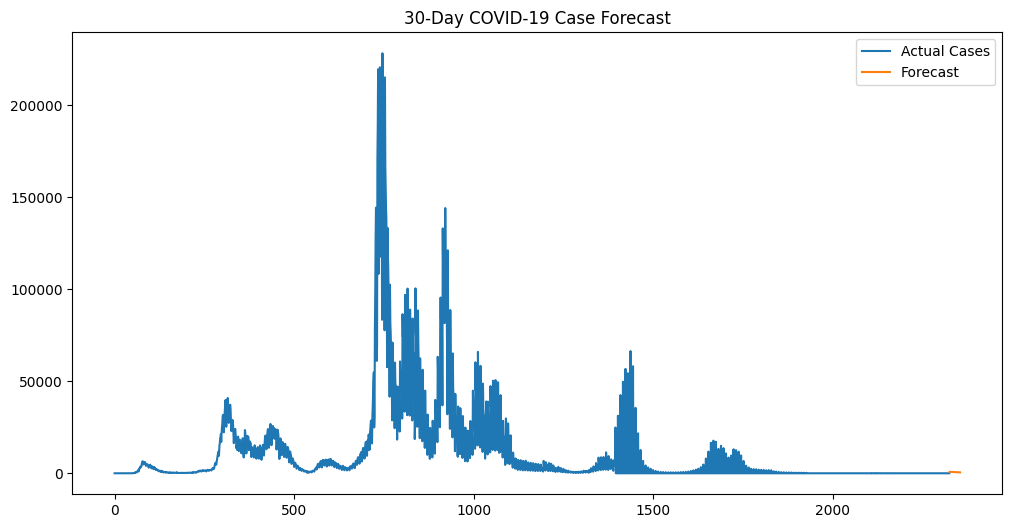

In [29]:
#Visualize Forecast
plt.figure(figsize=(12,6))

plt.plot(df['day_number'], y, label='Actual Cases')

plt.plot(
    future_days['day_number'],
    future_predictions,
    label='Forecast'
)

plt.legend()
plt.title("30-Day COVID-19 Case Forecast")
plt.show()

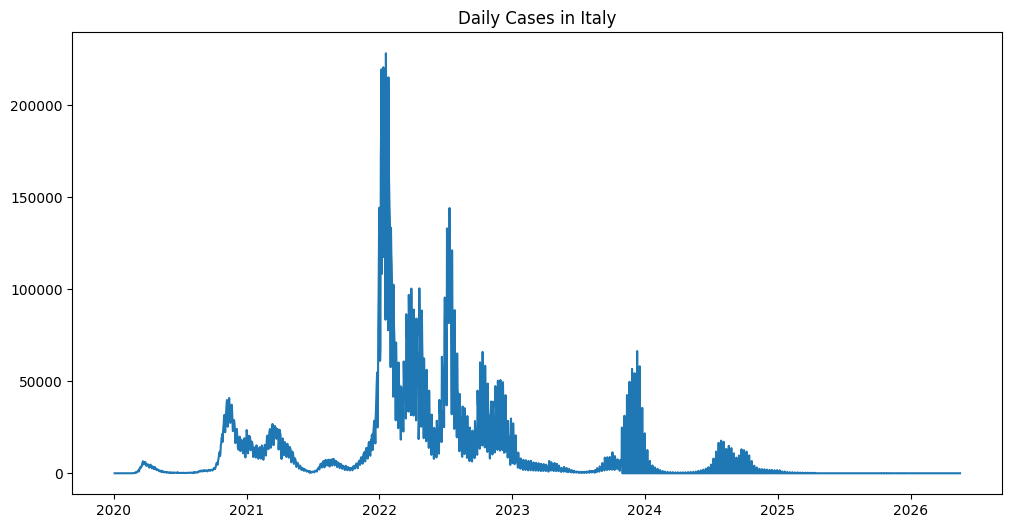

In [30]:
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['new_cases'])

plt.title('Daily Cases in Italy')

plt.savefig('daily_cases.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

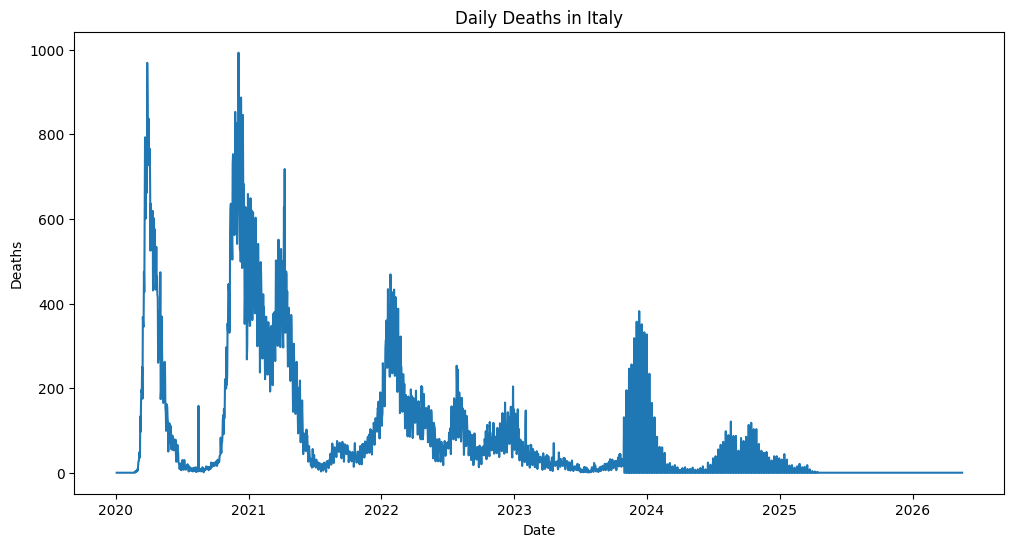

In [31]:
# daily deaths
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['new_deaths'])

plt.title('Daily Deaths in Italy')
plt.xlabel('Date')
plt.ylabel('Deaths')

plt.savefig('daily_deaths.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

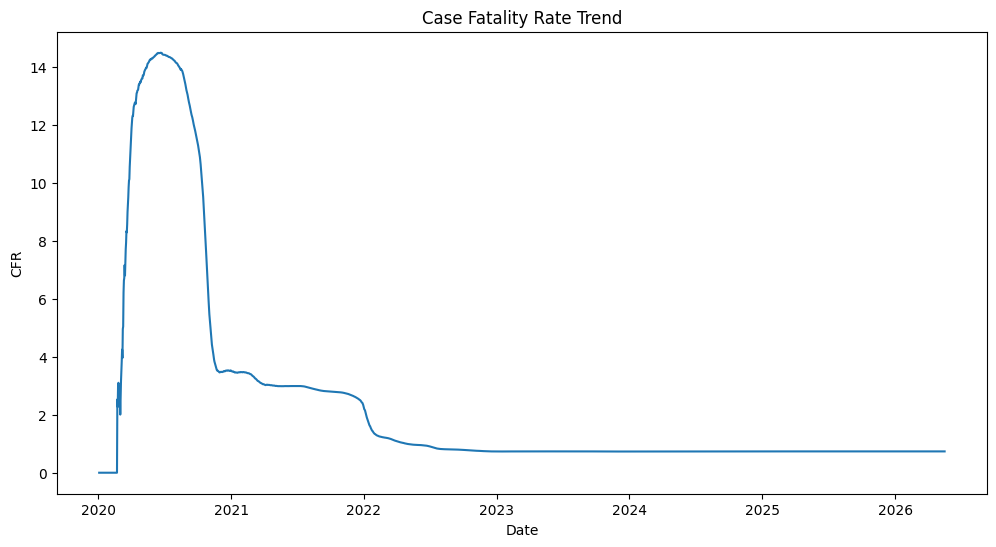

In [32]:
#cfr trend
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['cfr'])

plt.title('Case Fatality Rate Trend')
plt.xlabel('Date')
plt.ylabel('CFR')

plt.savefig('cfr_trend.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

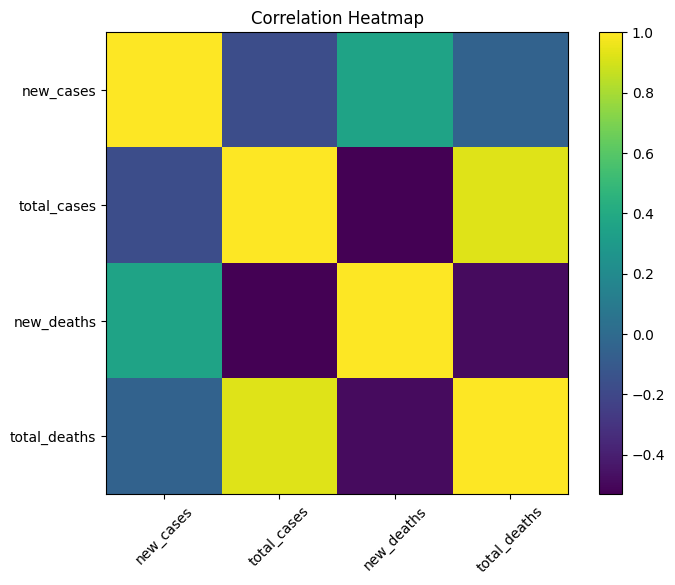

In [33]:
#correlation HeatMap
cols = [
    'new_cases',
    'total_cases',
    'new_deaths',
    'total_deaths'
]

corr = df[cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)

plt.title('Correlation Heatmap')

plt.savefig('correlation_heatmap.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

In [34]:
# 📊 COVID-19 Italy Data Analysis - Final Business Report

print("="*60)
print("🇮🇹 COVID-19 ITALY DATA ANALYSIS - FINAL REPORT")
print("="*60)

# Key KPIs
total_cases = df['total_cases'].max()
total_deaths = df['total_deaths'].max()
peak_cases = df['new_cases'].max()
peak_deaths = df['new_deaths'].max()

print("\n📌 KEY PERFORMANCE INDICATORS (KPIs)")
print("-"*60)
print(f"Total Confirmed Cases   : {total_cases:,.0f}")
print(f"Total Deaths            : {total_deaths:,.0f}")
print(f"Peak Daily Cases        : {peak_cases:,.0f}")
print(f"Peak Daily Deaths       : {peak_deaths:,.0f}")

# Time insights
peak_case_day = df.loc[df['new_cases'].idxmax(), 'date']
peak_death_day = df.loc[df['new_deaths'].idxmax(), 'date']

print("\n📅 CRITICAL EVENTS")
print("-"*60)
print(f"Highest Cases Recorded On : {peak_case_day}")
print(f"Highest Deaths Recorded On: {peak_death_day}")

# Trend insights
print("\n📈 KEY INSIGHTS")
print("-"*60)
print("✔ Italy experienced multiple COVID-19 waves over time")
print("✔ Cases and deaths show strong positive correlation")
print("✔ 7-day moving average reveals smoother long-term trends")
print("✔ CFR (fatality rate) decreased over time due to medical improvements")
print("✔ Significant spikes occurred during major outbreak periods")

# Data summary
print("\n📊 DATA SUMMARY")
print("-"*60)
print(f"Total Records Analyzed: {len(df):,}")
print(f"Time Period Covered   : {df['date'].min()} to {df['date'].max()}")

print("\n" + "="*60)
print("END OF REPORT - DATA SCIENCE PROJECT COMPLETE 🚀")
print("="*60)

🇮🇹 COVID-19 ITALY DATA ANALYSIS - FINAL REPORT

📌 KEY PERFORMANCE INDICATORS (KPIs)
------------------------------------------------------------
Total Confirmed Cases   : 26,969,913
Total Deaths            : 198,523
Peak Daily Cases        : 228,123
Peak Daily Deaths       : 993

📅 CRITICAL EVENTS
------------------------------------------------------------
Highest Cases Recorded On : 2022-01-19 00:00:00
Highest Deaths Recorded On: 2020-12-04 00:00:00

📈 KEY INSIGHTS
------------------------------------------------------------
✔ Italy experienced multiple COVID-19 waves over time
✔ Cases and deaths show strong positive correlation
✔ 7-day moving average reveals smoother long-term trends
✔ CFR (fatality rate) decreased over time due to medical improvements
✔ Significant spikes occurred during major outbreak periods

📊 DATA SUMMARY
------------------------------------------------------------
Total Records Analyzed: 2,326
Time Period Covered   : 2020-01-04 00:00:00 to 2026-05-17 00:00:00
